In [1]:
import os
import requests
import hashlib
import pandas as pd
from tqdm import tqdm

# --- CONTROLADOR DEL EXPERIMENTO ---
ANIO = 2024
SEMESTRE = 1  # Cambia a 1 (Ene-Jun) o 2 (Jul-Dic)
SYMBOL = "BTCUSDT"
TIMEFRAME = "15m"
# -----------------------------------

RAW_DIR = "../data/raw" 
BASE_URL = f"https://data.binance.vision/data/futures/um/monthly/klines/{SYMBOL}/{TIMEFRAME}/"
os.makedirs(RAW_DIR, exist_ok=True)

# Lógica para determinar los meses según el semestre elegido
if SEMESTRE == 1:
    start_date = f"{ANIO}-01-01"
    end_date = f"{ANIO}-06-01"
else:
    start_date = f"{ANIO}-07-01"
    end_date = f"{ANIO}-12-01"

fechas = pd.date_range(start=start_date, end=end_date, freq="MS")

def download_file(url, local_path):
    if os.path.exists(local_path):
        print(f"El archivo {os.path.basename(local_path)} ya existe. Saltando...")
        return True
    response = requests.get(url, stream=True)
    if response.status_code != 200:
        print(f"Error 404: No se encontró {url}")
        return False
    total_size = int(response.headers.get('content-length', 0))
    with open(local_path, 'wb') as file, tqdm(
        desc=os.path.basename(local_path), total=total_size, unit='iB', unit_scale=True, unit_divisor=1024
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)
    return True

def verify_checksum(zip_path, checksum_path):
    with open(checksum_path, 'r') as f:
        expected_hash = f.read().split()[0]
    sha256_hash = hashlib.sha256()
    with open(zip_path, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return expected_hash == sha256_hash.hexdigest()

print(f"Iniciando ingesta: Semestre {SEMESTRE} del {ANIO}...")

for fecha in fechas:
    mes_str = fecha.strftime("%Y-%m")
    zip_filename = f"{SYMBOL}-{TIMEFRAME}-{mes_str}.zip"
    checksum_filename = f"{zip_filename}.CHECKSUM"
    
    zip_url, checksum_url = BASE_URL + zip_filename, BASE_URL + checksum_filename
    zip_local_path, checksum_local_path = os.path.join(RAW_DIR, zip_filename), os.path.join(RAW_DIR, checksum_filename)
    
    if download_file(checksum_url, checksum_local_path):
        if download_file(zip_url, zip_local_path):
            if verify_checksum(zip_local_path, checksum_local_path):
                print(f" {mes_str} verificado.")
            else:
                print(f" ERROR: {zip_filename} corrupto.")

Iniciando ingesta: Semestre 1 del 2024...


BTCUSDT-15m-2024-01.zip.CHECKSUM: 100%|██████████| 90.0/90.0 [00:00<00:00, 584kiB/s]
BTCUSDT-15m-2024-01.zip: 100%|██████████| 142k/142k [00:00<00:00, 330kiB/s]  


 2024-01 verificado.


BTCUSDT-15m-2024-02.zip.CHECKSUM: 100%|██████████| 90.0/90.0 [00:00<00:00, 654kiB/s]
BTCUSDT-15m-2024-02.zip: 100%|██████████| 132k/132k [00:00<00:00, 633kiB/s]


 2024-02 verificado.


...

 2024-04 verificado.


BTCUSDT-15m-2024-05.zip.CHECKSUM: 100%|██████████| 90.0/90.0 [00:00<00:00, 660kiB/s]
BTCUSDT-15m-2024-05.zip: 100%|██████████| 141k/141k [00:00<00:00, 331kiB/s]  


 2024-05 verificado.


BTCUSDT-15m-2024-06.zip.CHECKSUM: 100%|██████████| 90.0/90.0 [00:00<00:00, 683kiB/s]
BTCUSDT-15m-2024-06.zip: 100%|██████████| 134k/134k [00:00<00:00, 312kiB/s]  

 2024-06 verificado.


Transformando temporalidad de 15m a 24h...


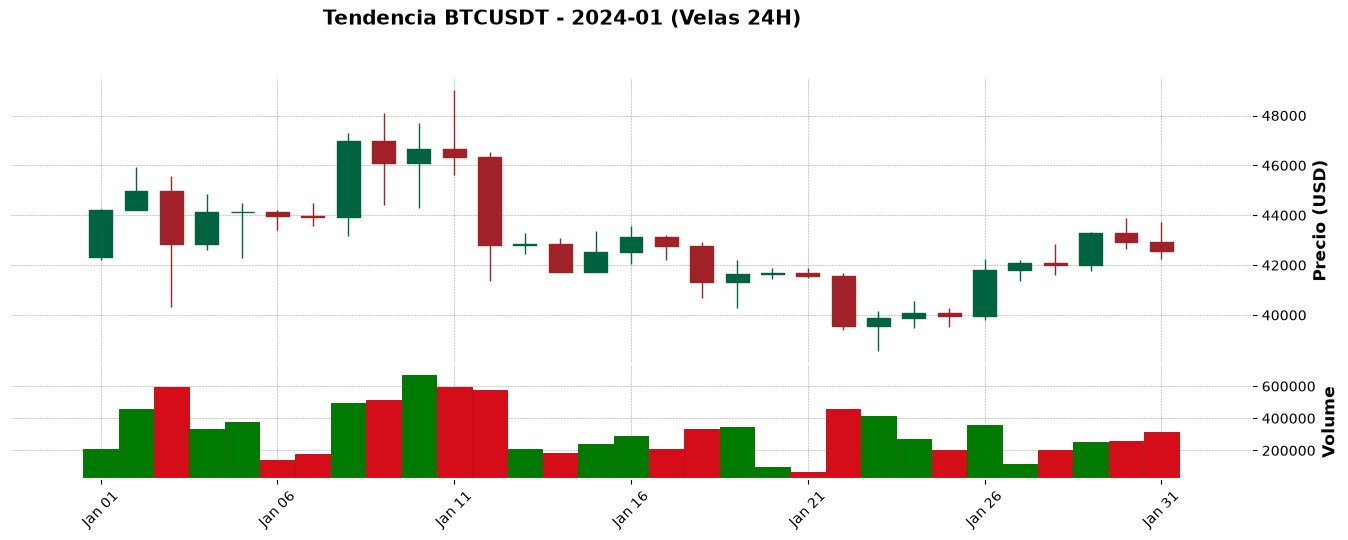

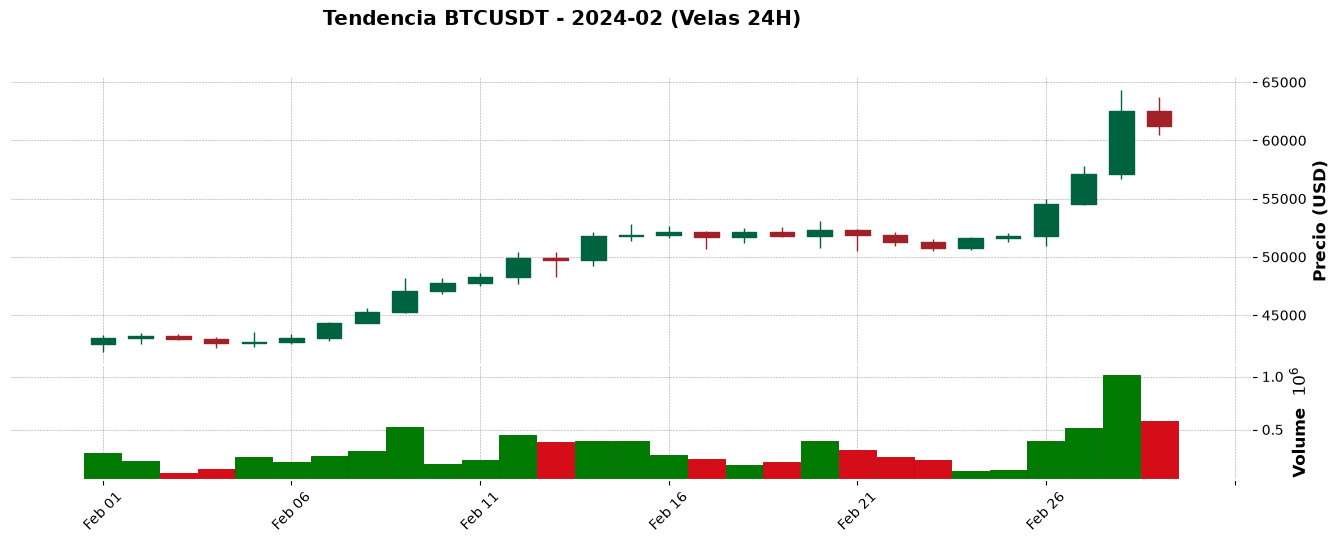

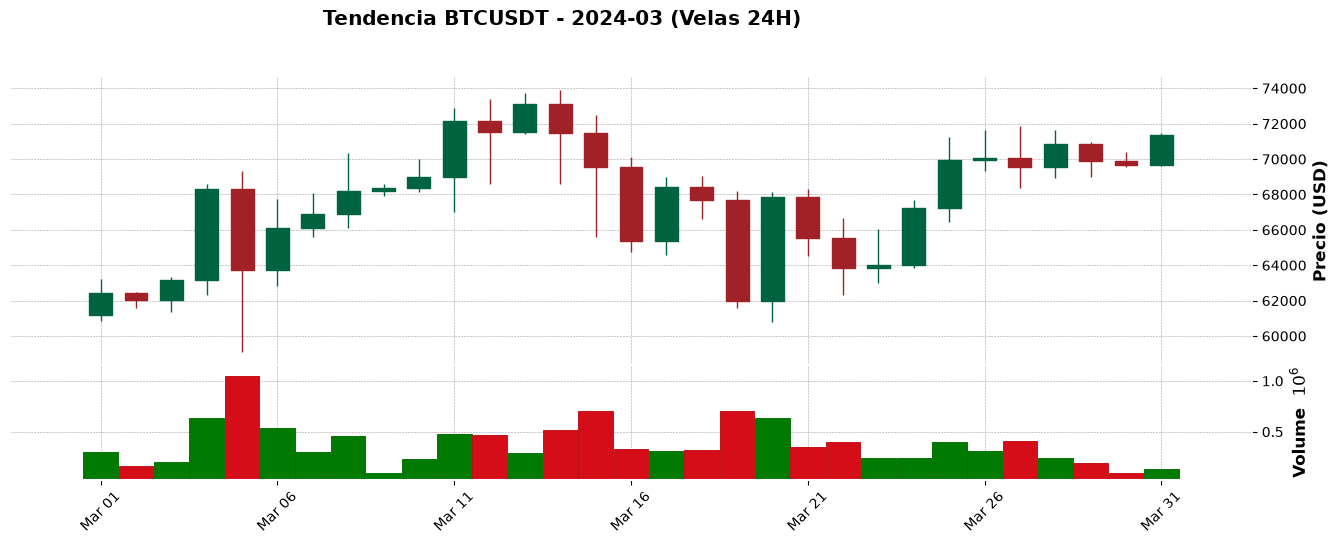

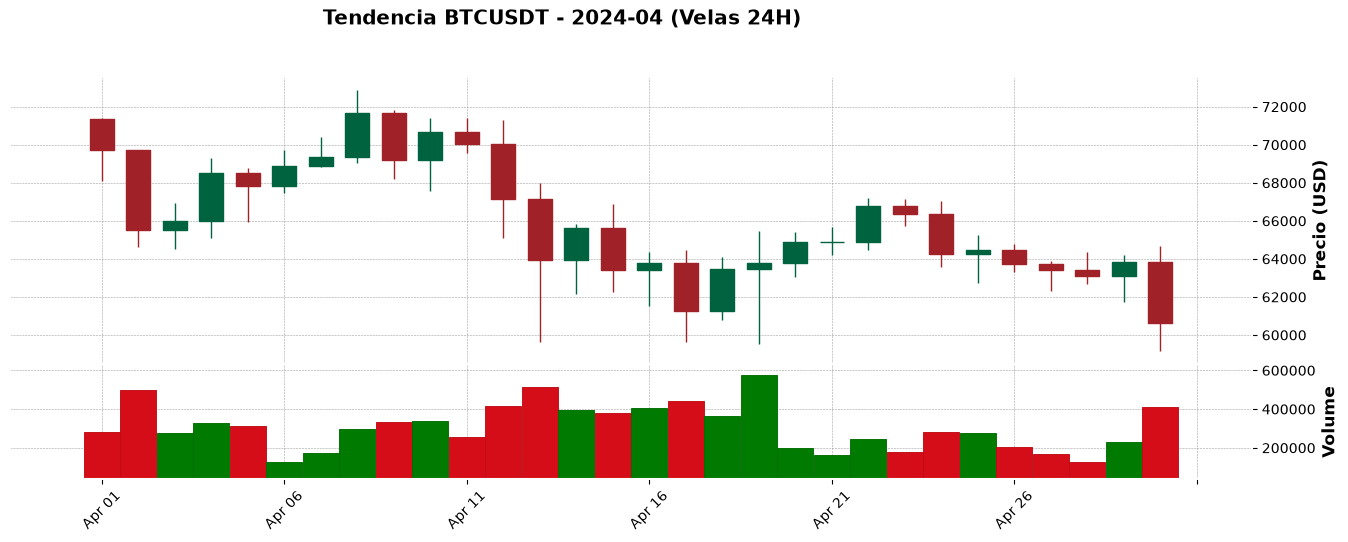

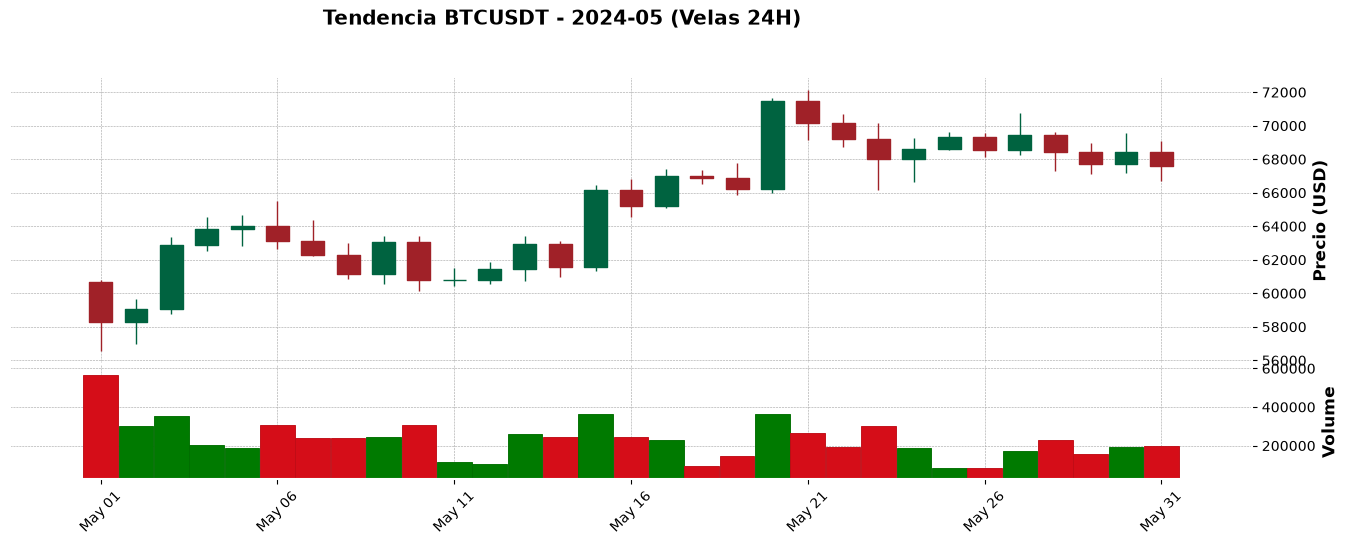

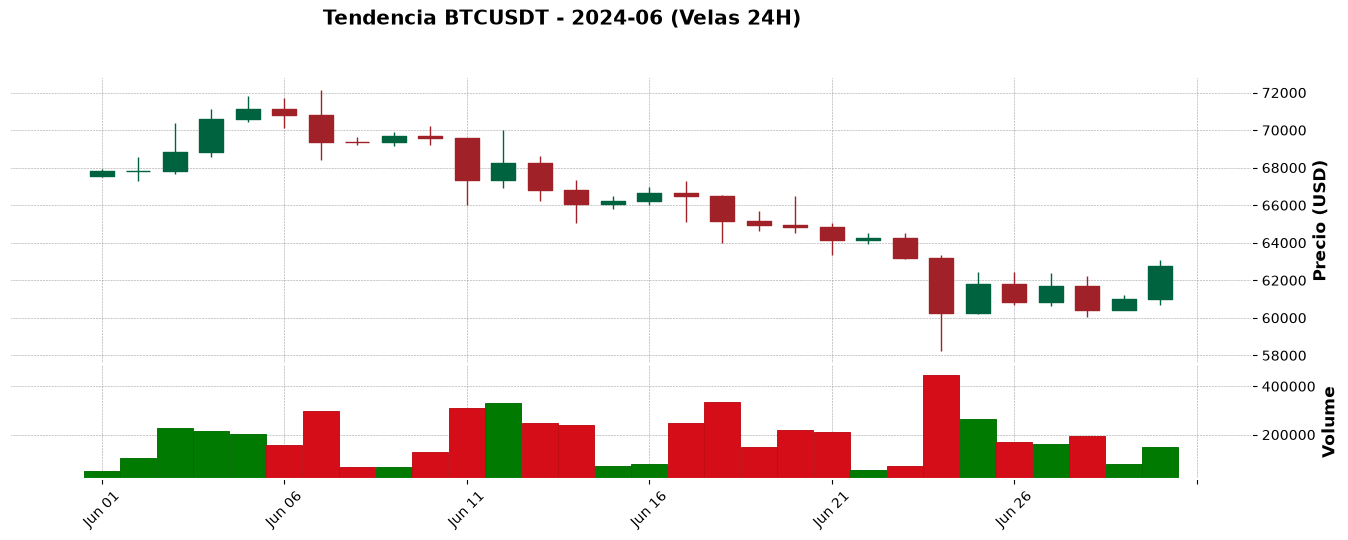

In [3]:
import mplfinance as mpf

import warnings
# Silencia las advertencias estéticas del administrador de fuentes
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

columnas = [
    'open_time', 'open', 'high', 'low', 'close', 'volume',
    'close_time', 'quote_asset_volume', 'number_of_trades',
    'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore'
]

lista_dfs = []
for fecha in fechas:
    mes_str = fecha.strftime("%Y-%m")
    zip_local_path = os.path.join(RAW_DIR, f"{SYMBOL}-{TIMEFRAME}-{mes_str}.zip")
    if os.path.exists(zip_local_path):
        df_mes = pd.read_csv(zip_local_path, names=columnas, dtype=str)
        lista_dfs.append(df_mes)

# Unimos y limpiamos (El mismo filtro estricto de antes)
df = pd.concat(lista_dfs, ignore_index=True)
df = df[df['open_time'] != 'open_time'].copy()
df['open_time'] = pd.to_numeric(df['open_time'])
df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
df.set_index('open_time', inplace=True)

columnas_numericas = ['open', 'high', 'low', 'close', 'volume']
df[columnas_numericas] = df[columnas_numericas].astype(float)

# --- RESAMPLEO MACRO ---
# Convertimos las velas de 15m a 24h (1D) para limpiar el ruido
print("Transformando temporalidad de 15m a 24h...")
df_24h = df.resample('1D').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}).dropna()

# --- GRAFICADO DINÁMICO POR MES ---
# Agrupamos por mes (ME = Month End) y generamos un gráfico por cada uno
for mes_timestamp, df_mes_grafico in df_24h.groupby(pd.Grouper(freq='ME')):
    if not df_mes_grafico.empty:
        mes_str = mes_timestamp.strftime("%Y-%m")
        mpf.plot(
            df_mes_grafico, 
            type='candle',
            style='charles',
            title=f'Tendencia BTCUSDT - {mes_str} (Velas 24H)',
            ylabel='Precio (USD)',
            volume=True,
            figratio=(12, 4)
        )

In [ ]:
# Nombres exactos de las columnas según la API de Binance
columnas = [
    'open_time', 'open', 'high', 'low', 'close', 'volume',
    'close_time', 'quote_asset_volume', 'number_of_trades',
    'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore'
]

lista_dfs = []

print("Leyendo y uniendo los archivos ZIP...")

for fecha in fechas:
    mes_str = fecha.strftime("%Y-%m")
    zip_filename = f"{SYMBOL}-{TIMEFRAME}-{mes_str}.zip"
    zip_local_path = os.path.join(RAW_DIR, zip_filename)
    
    # dtype=str lee todo como texto inicialmente para evitar conflictos si hay basura mezclada con números
    df_mes = pd.read_csv(zip_local_path, names=columnas, dtype=str)
    lista_dfs.append(df_mes)

# Concatenamos los 3 meses en un solo bloque
df = pd.concat(lista_dfs, ignore_index=True)

# ---------------------------------------------------------
# DEFENSA: Eliminamos las filas que contengan el encabezado original del CSV
# Esto nos protege sin importar si Binance puso el encabezado o no
df = df[df['open_time'] != 'open_time'].copy()
# ---------------------------------------------------------

# Forzamos las columnas de tiempo a ser números enteros antes de la conversión
df['open_time'] = pd.to_numeric(df['open_time'])
df['close_time'] = pd.to_numeric(df['close_time'])

# Convertimos los milisegundos de formato Unix a fechas legibles (UTC)
df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
df['close_time'] = pd.to_datetime(df['close_time'], unit='ms')

# Limpieza final
df = df.drop(columns=['ignore'])
df.set_index('open_time', inplace=True)

# Transformamos el resto de columnas financieras a flotantes (números decimales)
columnas_numericas = df.columns.drop('close_time')
df[columnas_numericas] = df[columnas_numericas].astype(float)

print(f"¡Listo! Tenemos {len(df)} velas de 15 minutos limpias.")
df.head()

In [ ]:
PROCESSED_DIR = "../data/processed"
# Aseguramos que la carpeta exista
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 1. El camino tradicional (CSV)
# Es fácil de abrir en Excel, pero es un formato de texto pesado, lento de procesar, 
# y la próxima vez que lo leas, Pandas olvidará que 'open_time' era una fecha.
csv_path = os.path.join(PROCESSED_DIR, "BTCUSDT_15m_2024_Q1.csv")
df.to_csv(csv_path)
print(f" CSV guardado exitosamente en: {csv_path}")

# 2. El camino del ingeniero de datos (Parquet)
# ¿Recuerdas la advertencia roja sobre 'pyarrow' en la primera celda? Aquí cobra sentido.
# Parquet es un formato columnar comprimido. Pesa una fracción del CSV, se lee en 
# milisegundos y preserva perfectamente la estructura de las fechas y números.
parquet_path = os.path.join(PROCESSED_DIR, "BTCUSDT_15m_2024_Q1.parquet")
try:
    df.to_parquet(parquet_path)
    print(f" Parquet guardado exitosamente en: {parquet_path}")
except ImportError:
    print("\n Te falta el motor para Parquet. Ejecuta en otra celda: !pip install pyarrow")

In [ ]:
!pip install pyarrow

In [ ]:
!pip install mplfinance

In [ ]:
import pandas as pd
import mplfinance as mpf
import os

# 1. Leer el archivo Parquet (Súper rápido y conserva los tipos de datos)
PROCESSED_DIR = "../data/processed"
parquet_path = os.path.join(PROCESSED_DIR, "BTCUSDT_15m_2024_Q1.parquet")

df = pd.read_parquet(parquet_path)

# 2. Las gráficas de velas japonesas necesitan ver un pedazo pequeño de tiempo. 
# Intentar graficar 8700 velas de golpe hace que se vea como una mancha negra de tinta.
# Vamos a filtrar solo la última semana de marzo.
df_semana = df.loc['2024-03-24':'2024-03-31']

# 3. Graficar con estilo profesional
mpf.plot(
    df_semana, 
    type='candle',        # Gráfico de velas
    style='charles',      # Colores clásicos (verde sube, rojo baja)
    title='BTCUSDT - Última Semana Marzo 2024 (15m)',
    ylabel='Precio (USD)',
    ylabel_lower='Volumen',
    volume=True,          # Agrega el gráfico de volumen abajo
    figratio=(12, 6)      # Proporción de la imagen
)

In [ ]:
# 1. Agrupamos los datos de 15 minutos en velas de 4 Horas (4h)
# La lógica financiera dicta: la apertura es la primera, el cierre es el último, 
# el máximo es el mayor de la ventana, el mínimo es el menor, y el volumen se suma.
df_4h = df.resample('4h').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
})

# 2. Eliminamos las filas vacías que se puedan generar en el proceso
df_4h = df_4h.dropna()

# 3. Graficamos el mes de marzo COMPLETO, pero ahora en resolución de 4H
mpf.plot(
    df_4h.loc['2024-03-01':'2024-03-31'], 
    type='candle',
    style='charles',
    title='BTCUSDT - Marzo 2024 (Velas agrupadas a 4H)',
    ylabel='Precio (USD)',
    volume=True,
    figratio=(12, 6)
)